# Aufgabe 2

In der zweiten Aufgabe sollten wir aus den Werten die wir gemessen und in 1 dargestellt haben Werte berechnen. Für die Si-Diode sollen wir den Emissionskoeffizienten bestimmen, für die Z-Diode die Z-Spannung, den Gleichstromwiderstand und den differentiellen Widerstand und für die LED sollen wir die Schleusenspannung und daraus die mittlere emittierte Wellenlänge bestimmen.

## Si-Diode

## 1) Si-Diode: Emissionskoeffizient $n$ aus dem linearen Bereich von $\ln(I)$ gegen $U$

### 1.1 Ausgangsgleichung (Shockley)
Für eine Diode gilt im Vorwärtsbetrieb näherungsweise die Shockley-Gleichung:

$$
I(U)=I_S\left(\exp\left(\frac{U}{n\,U_T}\right)-1\right)
$$

mit

$$
U_T=\frac{kT}{e}
$$


### 1.2 Näherung im passenden Messbereich
Im geeigneten Vorwärtsbereich ist der Exponentialterm sehr groß:

$$
\exp\left(\frac{U}{nU_T}\right)\gg 1
$$

Dann kann man „$-1$“ vernachlässigen:

$$
I \approx I_S\exp\left(\frac{U}{nU_T}\right)
$$

### 1.3 Linearisierung durch Logarithmus
Logarithmieren liefert:

$$
\ln(I)\approx \ln(I_S)+\frac{1}{nU_T}U
$$

Das ist die Form einer Geraden

$$
y = a + mU
$$

mit
- $y=\ln(I)$
- $a=\ln(I_S)$
- $m=\frac{1}{nU_T}$

### 1.4 Bestimmung von $n$
Aus der Steigung $m$ folgt:

$$
n=\frac{1}{mU_T}
$$

und mit $U_T=\frac{kT}{e}$:

$$
n=\frac{1}{m}\cdot \frac{e}{kT}
$$

Aus unserem Fit haben wir nun bestimmt (Wir haben $T=293,15K$ gesetzt): 
$$
m \approx 1,8269 \implies n = 2,1668
$$


m  = 1.826883e+01 1/V
n  = 2.1668


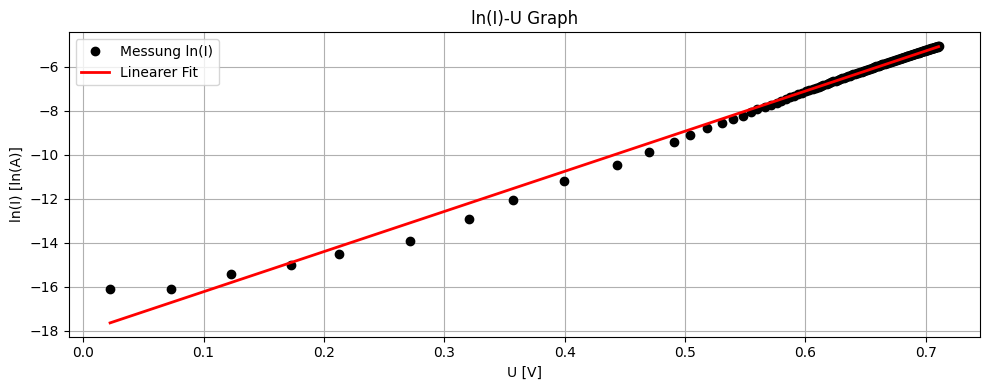

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df1 = pd.read_csv('Messungen/Si_Diode_Aufgabe1.csv')
df1.columns = df1.columns.str.replace('"', '').str.strip()

# Daten (nur Vorwärtsbereich + positive Ströme)
U = df1['U (V)'].to_numpy()
I = df1['I (A)'].to_numpy()
mask = (U > 0) & (I > 0)

U_f = U[mask]
I_f = I[mask]

# sortieren
idx = np.argsort(U_f)
U_f = U_f[idx]
I_f = I_f[idx]

lnI = np.log(I_f)

# ------------------------------------------------------------
# KOMPLETTER FIT in ln(I) = a + m*U  (über alle Vorwärtsdaten)
# ------------------------------------------------------------
m, a = np.polyfit(U_f, lnI, 1)   # ln(I) = m*U + a

# Fitgüte R^2
lnI_hat = m * U_f + a
ss_res = np.sum((lnI - lnI_hat) ** 2)
ss_tot = np.sum((lnI - np.mean(lnI)) ** 2)
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# ------------------------------------------------------------
# n aus der Steigung m
# m = 1/(n*UT)  =>  n = 1/(m*UT)
# ------------------------------------------------------------
T_K = 293.15  # ggf. anpassen
kB = 1.380649e-23
e  = 1.602176634e-19
UT = kB * T_K / e
n = 1.0 / (m * UT)

# Ausgabe
#print("=== Komplett-Fit: ln(I) = a + m*U ===")
print(f"m  = {m:.6e} 1/V")
#print(f"a  = {a:.6f}")
#print(f"R² = {r2:.6f}")
#print(f"UT = {UT*1e3:.3f} mV (bei T = {T_K:.2f} K)")
print(f"n  = {n:.4f}")

# Plot: ln(I) vs U + Fitgerade
plt.figure(figsize=(10, 4))
plt.plot(U_f, lnI, label="Messung ln(I)", marker='o', color="black", linewidth=0)
plt.plot(U_f, lnI_hat, label="Linearer Fit", color="red", linewidth=2)
plt.xlabel("U [V]")
plt.ylabel("ln(I) [ln(A)]")
plt.title("ln(I)-U Graph")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## 2) Z-Diode: Zenerspannung $U_Z$, Gleichstromwiderstand $R$ und differentieller Widerstand $r_d$

### 2.1 Zenerspannung $U_Z$ per Extrapolation
Im Durchbruchbereich (Sperrrichtung) ist die Kennlinie oft näherungsweise linear. Man betrachtet daher $U$ als Funktion von $I$:

$$
U(I)\approx aI+b
$$

Die **Extrapolation auf $I=0$** ergibt:

$$
U_Z = b
$$

Somit können wir aus unserem fit der Daten sehr einfach $U_Z$ bestimmen.

### 2.2 Widerstände bei $I = 0.2\,I_{Z,\max}$
Zuerst bestimmt man den maximal gemessenen Zenerstrom $I_{Z,\max}$ und dann:

$$
I_\text{target}=0.2\,I_{Z,\max}
$$

#### Gleichstromwiderstand $R$
Den Gleichstromwiderstand $R$ bekommen wir aus dem Ohmschen Gesetz an unserem Punkt $0.2\,I_{Z,\max}$

$$
R=\frac{U}{I}\quad \text{(am Punkt } I_\text{target}=0.2\,I_{Z,\max)}
$$

Bestimmen von U aus Messdaten: Man nimmt den Messpunkt, der $I_\text{target}$ am nächsten liegt, und setzt $U_\text{mess}$ und $I_\text{mess}$ ein:
  $$
  R \approx \frac{U_\text{mess}(I_\text{target})}{I_\text{target}}
  $$

#### Differentieller Widerstand $r_d$
Der differentielle Widerstand ist die lokale Steigung der Kennlinie:

$$
r_d=\frac{dU}{dI}
$$

Praktisch bedeutet das:
- $r_d$ ist die **lokale Steigung** der $U(I)$-Kurve in der Nähe von $I_\text{target}$  
- Man bestimmt $r_d$ typischerweise per lokaler linearer Regression um $I_\text{target}$

Wenn man im linearen Durchbruchbereich ohnehin den Fit
$$
U(I)=aI+b
$$
verwendet, dann ist die Ableitung konstant und ergibt direkt:

$$
r_d = a
$$

Also werden wir unseren Knickpunkt suchen und ab diesem einen linearen Fit unserer Funktion zu finden. Aus diesem Fit können wir dann $U_Z$ und $r_d$ bestimmen. Aus den restlichen Messdaten können wir sehr einfach noch den Gleichstromwiderstand $R$ bestimmen.

Uz       = 6.722736 V
rd       = 7.12 Ohm
R = 6485.99 Ohm bei I_target = 1037.64 µA


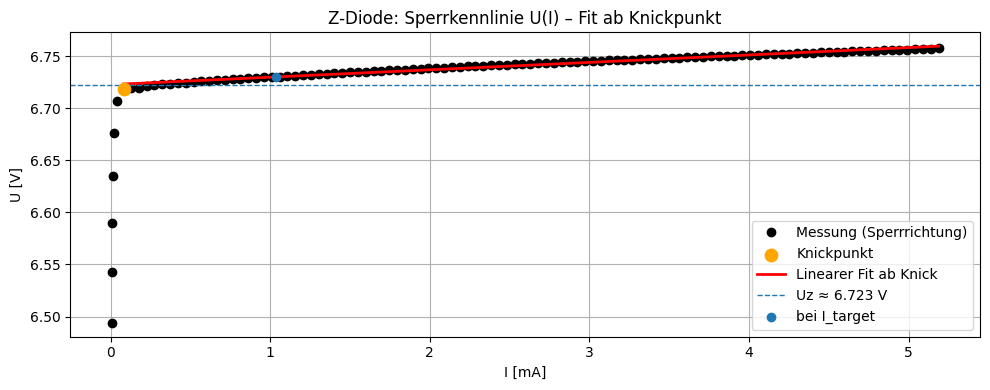

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Hardcoded Knickpunkt aus deiner Zeile ---
I_KNICK = 80.833333e-6   # A
U_KNICK = 6.718781       # V  (nur zur Info/Plot)

# CSV einlesen
df = pd.read_csv('Messungen/Z_Diode_Antidurchlass_Aufgabe1_2.csv')
df.columns = df.columns.str.replace('"', '').str.strip()

# Daten
I = df['I (A)'].to_numpy()
U = df['U (V)'].to_numpy()

# sortieren nach I
idx = np.argsort(I)
I = I[idx]
U = U[idx]
kink_idx = int(np.argmin(np.abs(I - I_KNICK)))

I_fit = I[kink_idx:]
U_fit = U[kink_idx:]

if len(I_fit) < 2:
    raise ValueError("Zu wenige Punkte ab Knickpunkt für Fit.")

b, a = np.polyfit(I_fit, U_fit, 1)   # U = b*I + a
U_hat = a + b * I_fit

# R² im Fitbereich
ss_res = np.sum((U_fit - U_hat) ** 2)
ss_tot = np.sum((U_fit - np.mean(U_fit)) ** 2)
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# Parameter
Uz = a          # Extrapolation auf I=0
rd = b          # rd = dU/dI

# -------------------------
# R bei I_target = 0.2 * Iz_max (aus Antidurchlassdaten)
# -------------------------
Iz_max = np.max(I)
I_target = 0.2 * Iz_max

U_target = Uz + rd * I_target
R = U_target / I_target if I_target != 0 else np.nan

# Ausgabe
print(f"Uz       = {Uz:.6f} V")
print(f"rd       = {rd:.2f} Ohm")
print(f"R = {R:.2f} Ohm bei I_target = {I_target*1e6:.2f} µA")

# -------------------------
# Plot: U(I) + Fit + Knickpunkt
# -------------------------
plt.figure(figsize=(10, 4))
plt.plot(I*1e3, U, label="Messung (Sperrrichtung)", color="black", linewidth=0, marker='o')

# Knickpunkt markieren (Datenpunkt)
plt.scatter([I[kink_idx]*1e3], [U[kink_idx]], label="Knickpunkt", color="orange", s=80, zorder=4)

# Fitlinie (ab Knick)
I_line = np.linspace(I_fit.min(), I_fit.max(), 200)
U_line = Uz + rd * I_line
plt.plot(I_line*1e3, U_line, label="Linearer Fit ab Knick", color="red", linewidth=2)

# Uz Linie + I_target Punkt
plt.axhline(Uz, linestyle="--", linewidth=1, label=f"Uz ≈ {Uz:.3f} V")
plt.scatter([I_target*1e3], [U_target], label="bei I_target", zorder=5)

plt.xlabel("I [mA]")
plt.ylabel("U [V]")
plt.title("Z-Diode: Sperrkennlinie U(I) – Fit ab Knickpunkt")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Somit haben wir für unsere Z-Diode die folgenden Werte aus den Messdaten mit Fit bestimmt: $U_Z = \approx 7,723 V$, $r_d \approx 7,12 \Omega$ und $R \approx 6486 \Omega$

## LED

## 3) LED: Schleusenspannung $U_S$ und Wellenlänge $\lambda$

### 3.1 Schleusenspannung $U_S$ aus dem linearen Teil von $I(U)$
Im passenden Bereich kann man die LED-Kennlinie näherungsweise als linear ansetzen:

$$
I \approx mU + b
$$

Die Spannung, bei der der lineare Fit $I=0$ ergibt, ist:

$$
U_S = -\frac{b}{m}
$$

### 3.2 Wellenlänge aus $U_S$
Wenn man annimmt, dass die elektrische Energie pro Ladung ungefähr als Photonenergie abgegeben wird:

$$
eU_S = h\nu
$$

und mit

$$
c=\lambda \nu
$$

folgt

$$
\lambda=\frac{hc}{eU_S}
$$


Das heißt um unsere gesuchten Werte zu bestimmen, versuchen wir einen guten fit für den linearen teil unserer Kennlinie zu finden und aus diesem Fit dann den Wert $U_S$ zu berechnen. Aus diesem können wir dann wiederrum die Wellenlänge berechnen.

Us = 1.828785 V
lambda = 677.96 nm


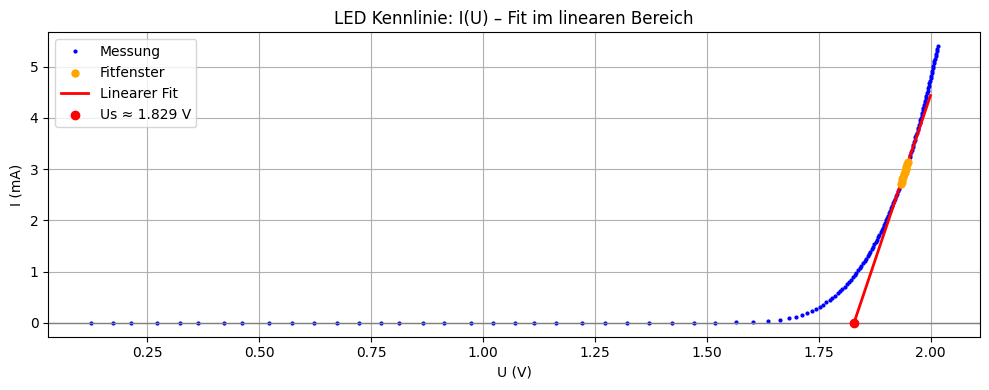

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Konstanten
E_CHARGE = 1.602176634e-19  # C
H = 6.62607015e-34          # J*s
C0 = 299792458.0            # m/s

# CSV einlesen
df = pd.read_csv('Messungen/Leuchtdiode_Aufgabe1.csv')
df.columns = df.columns.str.replace('"', '').str.strip()

# Daten
U = df['U (V)'].to_numpy()
I = df['I (A)'].to_numpy()

# Vorwärtsbereich
mask = (U > 0) & (I >= 0)
U_f = U[mask]
I_f = I[mask]

# sortieren nach U
idx = np.argsort(U_f)
U_f = U_f[idx]
I_f = I_f[idx]

# ------------------------------------------------------------
# bestes lineares Fitfenster finden (wie vorher)
# ------------------------------------------------------------
def best_linear_window(Ux, Iy, min_pts=10, max_pts=40, I_min_mA=0.2):
    I_min = I_min_mA * 1e-3  # mA -> A
    m = Iy >= I_min
    Ux = Ux[m]
    Iy = Iy[m]

    if len(Ux) < min_pts:
        raise ValueError("Zu wenige Punkte oberhalb I_min. Setze I_min_mA kleiner.")

    n = len(Ux)
    max_pts = min(max_pts, n)
    best = (0, min_pts, -np.inf, None, None)  # start, end, r2, a, b

    for w in range(min_pts, max_pts + 1):
        for i0 in range(0, n - w + 1):
            i1 = i0 + w
            Uwin = Ux[i0:i1]
            Iwin = Iy[i0:i1]

            b, a = np.polyfit(Uwin, Iwin, 1)  # I = bU + a
            if b <= 0:
                continue

            I_hat = a + b * Uwin
            ss_res = np.sum((Iwin - I_hat) ** 2)
            ss_tot = np.sum((Iwin - np.mean(Iwin)) ** 2)
            r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else -np.inf

            score = r2 + 1e-6 * w
            if score > best[2]:
                best = (i0, i1, r2, a, b)

    return best, Ux, Iy


(best_i0, best_i1, r2, a, b), U_lin, I_lin = best_linear_window(
    U_f, I_f,
    min_pts=10,
    max_pts=40,
    I_min_mA=0.2
)

# Us und lambda
Us = -a / b
lambda_m = (H * C0) / (E_CHARGE * Us)
lambda_nm = lambda_m * 1e9
#Ausgabe
print(f"Us = {Us:.6f} V")
print(f"lambda = {lambda_nm:.2f} nm")

# ------------------------------------------------------------
# Fitlinie NUR als "verlängerte Tangente":
# von Us bis (z.B.) Ende des Fitfensters + kleiner Rand
# ------------------------------------------------------------
U_top = U_lin[best_i1 - 1] + 0.05  # 50 mV über Fenster-Ende (kannst du anpassen)
U_fit_segment = np.linspace(Us, U_top, 300)
I_fit_segment = a + b * U_fit_segment

# Plot
plt.figure(figsize=(10, 4))
plt.plot(U_f, I_f * 1e3, label="Messung", color="blue", linewidth=0, marker='o', markersize=2)

# Fitfenster markieren
plt.scatter(U_lin[best_i0:best_i1], I_lin[best_i0:best_i1] * 1e3,
            label="Fitfenster", color="orange", s=25, zorder=3)

# Fitgerade nur als Segment (wie deine schwarze Linie)
plt.plot(U_fit_segment, I_fit_segment * 1e3, label="Linearer Fit", color="red", linewidth=2)

# I=0 Linie + Us markieren
plt.axhline(0, color="gray", linewidth=1)
plt.scatter([Us], [0], color="red", zorder=5, label=f"Us ≈ {Us:.3f} V")

plt.xlabel("U (V)")
plt.ylabel("I (mA)")
plt.title("LED Kennlinie: I(U) – Fit im linearen Bereich")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Wir haben für unsere Schleusenspannung $U_S \approx 1,829 V$ herausbekommen und somit für die mittlere Wellenlänger $\lambda \approx 677,96 nm$. Das passt genau zu unseren Beobachtungen, da wir eine rote LED betrachtet haben und diese Wellenlänge genau im Bereich von rotem Licht ist.


# Fehlerbetrachtung

Bei unserem Versuch selber wurden die Messwerte automatisch aufgenommen und da wir beim Spannung und Strommessen immer leichte Abweichungen haben kann es dort durch mitteln der Werte auch zu Abweichungen gekommen sein. Außerdem haben wir im Auswerten die meisten unserer Werte mithilfe von Fits bestimmt, welche z.B. bei der LED in ungefähr linearen Bereichen waren. Dadurch kann es zu größeren Abweichungen kommen, da die Fits nicht genau den Verlauf unserer Messwerte darstellen. Bei der bestimmung des Emissionskoeffizienten kam es außerdem auf die Temperatur an, die wir nicht genau wussten und somit geschätzt haben.